##Реализация модели линейной регрессии и сравнение Lasso- и Ridge-регуляризаций

Импортируем датасет с информацией о бриллиантах ([описание](https://www.kaggle.com/shivam2503/diamonds)).

In [ ]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Обработка пропусков**

Проверим наличие пропусков в наборе данных. В случае, если они есть, удалим их.

Далее проверим, все ли признаки являются содерждательными.

In [ ]:
#количество пропусков в каждом столбце
data.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

Вывод:\
Пропущенных значений нет, есть бессмысленный столбец "Unnamed: 0".

In [ ]:
#удаление столбца "Unnamed: 0"
data = data[data.columns.drop("Unnamed: 0")]
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Построение матрицы корреляций**

Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется.

Построим и проанализируем матрицу корреляций между всеми вещественными признаками и целевой переменной.

In [ ]:
corr_matrix = pd.DataFrame(data.corr(numeric_only = True)["price"])
corr_matrix

,price
carat,0.921591
depth,-0.010647
table,0.127134
price,1.000000
x,0.884435
y,0.865421
z,0.861249


Вывод:\
Наибольшую корреляцию с целевой переменной "price" имеют признаки "carat" (вес бриллианта) и "x", "y", "z" (длина, ширина, глубина бриллианта).

**Обработка категориальных признаков**

Закодируем категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [ ]:
data = pd.get_dummies(data, drop_first=True, dtype=float)
data.head()

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.21,59.8,61.0,326,3.89,3.84,2.31,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.23,56.9,65.0,327,4.05,4.07,2.31,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.29,62.4,58.0,334,4.20,4.23,2.63,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.31,63.3,58.0,335,4.34,4.35,2.75,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


**Разделение выборки на тренировочную и тестовую**

Разделим выборку на тренировочную и тестовую. Долю тестовой выборки возьмем равной 0.3.

In [ ]:
from sklearn.model_selection import train_test_split
X = data[data.columns.drop("price")]
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.3)

**Масштабирование признаков**

Стандартизируем вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [ ]:
from sklearn.preprocessing import StandardScaler

#масштабирование признаков
scaler = StandardScaler()
X_train_float_feat_scaled = pd.DataFrame(data=scaler.fit_transform(X_train.iloc[:, :6].values), columns=X_train.iloc[:, :6].columns, index=X_train.index)
X_test_float_feat_scaled = pd.DataFrame(data=scaler.transform(X_test.iloc[:, :6].values), columns=X_test.iloc[:, :6].columns, index=X_test.index)
X_train_scaled = X_train_float_feat_scaled.join(X_train.iloc[:, 6:])
X_test_scaled = X_test_float_feat_scaled.join(X_test.iloc[:, 6:])
X_train_scaled.head()

,carat,depth,table,x,y,z,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
16259,0.445813,0.170523,-0.201734,0.630510,0.540663,0.605461,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
24005,1.562356,0.588814,-0.649638,1.503049,1.397771,1.519486,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12211,0.740749,0.937389,2.485693,0.799676,0.687843,0.858576,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
37918,-0.818197,-0.805489,-0.201734,-0.838559,-0.775299,-0.871040,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
181,-0.544328,-0.178053,-0.201734,-0.437904,-0.411678,-0.435121,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Примечание:\
Масштабирование признаков позволяет судить о его важности (силе влияния) на целевую переменную. До этого все признаки измерялись в разных единицах и не могли быть сравнимы между собой.

**Обучение и инференс модели**

Обучим линейную регрессию на тренировочной выборке и выведем среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
r2 = r2_score(y_train, lr.predict(X_train_scaled))

mse_train = mean_squared_error(y_train, lr.predict(X_train_scaled))
mse_test = mean_squared_error(y_test, lr.predict(X_test_scaled))

print(f'R2 score in the training sample is: {np.round(r2, 3)}')
print(f'Mean Square Error in the training sample is: {np.round(mse_train, 3)}')
print(f'Mean Square Error in the testing sample is: {np.round(mse_test, 3)}')

R2 score in the training sample is: 0.919
Mean Square Error in the training sample is: 1284661.862
Mean Square Error in the testing sample is: 1259159.114


Вывод:\
Модель описывает около 92% разброса (дисперсии) цены на бриллианты в тренировочной выборке, что говорит о том, что предикторы очень хорошо описывают имеющуюся зависимость. Более того, ошибка на тестовой выборке меньше, чем на тренировочной, что говорит об отсутствии переобучения.

**Вывод коэффициентов**

Изучим [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведем полученные оценки коэффициентов.

In [ ]:
coefficients = lr.coef_
print(coefficients)

[ 5.27811998e+03 -9.42669361e+01 -6.56183723e+01 -1.05002476e+03
 -2.64737971e+00 -4.05686230e+01  5.41639869e+02  7.95786817e+02
  7.21797535e+02  6.98433173e+02 -1.80617972e+02 -2.36924694e+02
 -4.50558533e+02 -9.43618044e+02 -1.42880833e+03 -2.34337515e+03
  5.33355507e+03  3.67037809e+03  2.70186810e+03  4.59244827e+03
  4.27255738e+03  5.02155858e+03  4.95459850e+03]


In [ ]:
columns = np.array(X_train_scaled.columns)
columns

array(['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_Good', 'cut_Ideal',
       'cut_Premium', 'cut_Very Good', 'color_E', 'color_F', 'color_G',
       'color_H', 'color_I', 'color_J', 'clarity_IF', 'clarity_SI1',
       'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1',
       'clarity_VVS2'], dtype=object)

In [ ]:
for coef, col in zip(coefficients[0:6], columns[0:6]):
    if np.abs(coef) > 100:
        print(coef, col)

5278.119983938968 carat
-1050.024759755721 x


Вывод:\
Очень высокие оценки коэффициентов имеют вещественные переменные "carat" (вес бриллианта) и "x" (длина бриллианта).

**Регуляризация**

В соответствии с анализом корреляционной матрицы, проведенным ранее, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей пункте также намекают на её присутствие. Для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Воспользуемся вторым вариантом.

Смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучим Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используем модули `Lasso` и `Ridge` из `sklearn`.

In [ ]:
coefficients

array([ 5.27811998e+03, -9.42669361e+01, -6.56183723e+01, -1.05002476e+03,
       -2.64737971e+00, -4.05686230e+01,  5.41639869e+02,  7.95786817e+02,
        7.21797535e+02,  6.98433173e+02, -1.80617972e+02, -2.36924694e+02,
       -4.50558533e+02, -9.43618044e+02, -1.42880833e+03, -2.34337515e+03,
        5.33355507e+03,  3.67037809e+03,  2.70186810e+03,  4.59244827e+03,
        4.27255738e+03,  5.02155858e+03,  4.95459850e+03])

In [ ]:
from sklearn.linear_model import Lasso, Ridge
lasso = Lasso(10.0).fit(X_train_scaled, y_train)
print("Lasso")
print(lasso.coef_)

ridge = Ridge(10.0).fit(X_train_scaled, y_train)
print("\nRidge")
print(ridge.coef_)

Lasso
[ 4.71743050e+03 -1.53897630e+02 -1.14359498e+02 -6.34665961e+02
 -0.00000000e+00 -2.38637594e+01 -0.00000000e+00  1.57773311e+02
  6.49642121e+01  8.29123605e+01  2.89245109e+00  0.00000000e+00
 -1.11417566e+02 -5.94797373e+02 -9.89237948e+02 -1.78579096e+03
  1.36634737e+03  7.08619218e+01 -7.35084934e+02  9.09413824e+02
  6.55593919e+02  1.24299124e+03  1.24071029e+03]

Ridge
[ 5.22844129e+03 -9.72441606e+01 -6.85479296e+01 -1.01276713e+03
 -1.71800611e+00 -4.16912899e+01  5.64972250e+02  8.23308089e+02
  7.46147154e+02  7.27722546e+02 -1.68557828e+02 -2.23702621e+02
 -4.33182440e+02 -9.26878179e+02 -1.40434915e+03 -2.30843494e+03
  4.76047220e+03  3.14279042e+03  2.18215462e+03  4.05576226e+03
  3.74139226e+03  4.47074534e+03  4.41139173e+03]


Вывод:\
В результате применения Lasso-регрессии веса довольно сильно уменьшились, однако в результате применения Ridge-регрессии изменения совсем незначительные. Посмотрев на веса, полученные в результате применения Lasso-модели, можно увидеть, что некоторые из них обнулились, значит, они были неважными или коррелировали с другими признаками. Таким образом, в исходной модели мультиколлинеарность скорее всего была.

**Визуализация изменения евклидовой нормы весов в зависимости от величины параметра регуляризации**

Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучим Lasso- и Ridge-регрессии и построим график изменения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

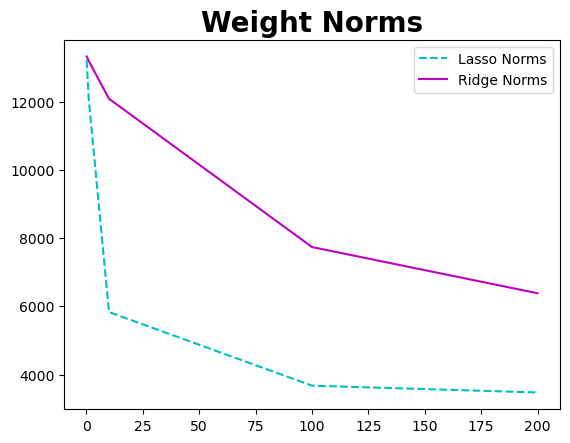

In [ ]:
alpha = [0.1, 1, 10, 100, 200]
lasso_norms = []
ridge_norms = []

for a in alpha:
    lasso = Lasso(a).fit(X_train_scaled, y_train)
    ridge = Ridge(a).fit(X_train_scaled, y_train)
    lasso_norm = np.linalg.norm(lasso.coef_)
    lasso_norms.append(lasso_norm)
    ridge_norm = np.linalg.norm(ridge.coef_)
    ridge_norms.append(ridge_norm)

plt.figure()
plt.title("Weight Norms", size=20, weight="heavy")
x = alpha
y1 = lasso_norms
y2 = ridge_norms
plt.plot(x, y1, c="c", linestyle="--", label="Lasso Norms") #нанесение 1-ого графика
plt.plot(x, y2, c="m", label="Ridge Norms") #нанесение 2-ого графика
plt.legend()
plt.show()

Вывод:\
Метод Lasso сильнее снижает норму коэффициентов, так как он способен занулять незначимые для модели веса, "выкидывать" их из нее и сохранять только те, которые оказывают значительное влияние на результат. Таким образом Lasso-регрессия предотвращает переобучение модели и снижает риск мультиколлинеарности.

**Подбор оптимального значения параметра регуляризации**

В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Подберем оптимальное значение $\alpha$ при помощи кросс-валидации по тренировочной выборке.

In [ ]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, alphas=[0.1, 1, 10, 100, 200], random_state=0).fit(X_train_scaled, y_train)
mean_mse_alpha = []
for mse, alpha in zip(lasso.mse_path_, lasso.alphas_):
    mean_mse_alpha.append((np.round(np.mean(mse), 2), alpha))
min_mse = min(mean_mse_alpha, key=lambda x: x[0])
print(f'Наибольшее качество дает alpha = {min_mse[1]}.')

C:\Anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1177271856.726532, tolerance: 48309472.87280813
  model = cd_fast.enet_coordinate_descent_gram(


Наибольшее качество дает alpha = 1.0.


**Обучение модели**

Обучим итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке и выведем полученные коэффициенты.

In [ ]:
lasso = Lasso(1.0).fit(X_train_scaled, y_train)
print(lasso.coef_)

[ 5219.22347004  -103.13762135   -72.1147423  -1009.83968765
    -0.           -38.51315893   437.82050935   694.91027222
   619.88427512   601.60047184  -127.15409692  -183.44785077
  -392.82799349  -885.21920917 -1360.43955047 -2263.2030689
  4792.95148523  3171.13910035  2206.8162007   4082.07719954
  3770.07330299  4500.32277913  4440.81059919]


In [ ]:
for coef, col in zip(lasso.coef_, columns):
    if coef == 0:
        print(coef, col)

-0.0 y


In [ ]:
for coef, col in zip(lasso.coef_, columns):
    if np.abs(coef) > 2500:
        print(coef, col)

5219.22347003968 carat
4792.951485229572 clarity_IF
3171.1391003520603 clarity_SI1
4082.0771995429363 clarity_VS1
3770.0733029947423 clarity_VS2
4500.322779129321 clarity_VVS1
4440.810599187433 clarity_VVS2


Вывод:\
Неинформативным оказался признак "y" (ширина бриллианта), а наиболее информативными - "carat" (вес бриллианта) и "clarity" (чистота, прозрачность бриллианта). Вес бриллианта (в каратах) наиболее сильно влияет на его цену, т.к. крупные, тяжелые бриллианты встречаются очень редко, их добыча гораздо сложнее, поэтому и стоимость таких редких объектов будет очень высокой. Чистота бриллианта, в свою очередь, является характеристикой его внешнего вида, на которую тоже всегда обращают внимание: есть ли царапины, трещины в камне и т.п. Ширина бриллианта не сильно влияет на его стоимость вероятно из-за того, что другие характеристики оказываются для покупателей более важными. Кроме того, ширина, как и вес, характеризуют размер камня, а потому вес тоже может дать информацию о ширине.

**Инференс модели**

Выполним предсказания обученной Lasso-регрессии на тестовой выборке и сравним среднеквадратичную ошибку с ошибкой обычной линейной регрессии, реализованной несколькими шагами выше.

In [ ]:
lasso = Lasso(1.0)
lasso.fit(X_train_scaled, y_train)
mse_test_lasso = mean_squared_error(y_test, lasso.predict(X_test_scaled))
mse_test_lasso

1266198.458052361

Вывод:\
MSE для Lasso - 1266198.46, а для обычной линейной регресии - 1259159.11. Исходя из значений среднеквадратичных ошибок, для предсказаний следует использовать модель обычной линейной регресии, так как ее ошибка меньше. Вероятно, использованный коэффициент регуляризации оказался достаточно сильным и модель исключила признаки, которые на самом деле улучшали предсказание. При проведении кросс-валидации как раз высвечивалось предупреждение о том, что количество итераций (рассматриваемых коэффициентов регуляризации) слишком маленькое, поэтому был подобран не самый оптимальный коэффициент.